# Домашнее задание 3: прогнозирование волатильности SBER

В этом ноутбуке реализован полный пайплайн прогнозирования волатильности для **SBER** на основе **часовых свечей T-Invest API** за последние **5 лет**.

Что сделано в работе:
- загрузка рыночных данных через `T-Invest API`
- построение признаков для прогноза волатильности
- базовая статистическая модель `GARCH(1,1)`
- модель глубокого обучения `GRU`
- walk-forward валидация без утечки данных
- бэктест с volatility targeting, `Sharpe` и `Max Drawdown`
- моделирование будущих сценариев методом Монте-Карло



In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels arch python-dateutil
%pip install -q cachetools==5.5.2 deprecation "protobuf<5" "grpcio>=1.59.3"
%pip install -q --no-deps git+https://github.com/RussianInvestments/invest-python.git@0.2.0-beta97
%pip install -q torch

print('Среда готова к работе.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Среда готова к работе.


## Подготовка среды



In [2]:
from pathlib import Path
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from tinkoff.invest import Client, CandleInterval

# Базовый стиль для всех графиков в ноутбуке.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 13

# Фиксируем random seed, чтобы результаты DL-модели были воспроизводимее.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Основные параметры эксперимента.
TICKER = 'SBER'
FIGI = 'BBG004730N88'
LOOKBACK = 24
MIN_TRAIN_YEARS = 2
TEST_MONTHS = 6

END_DATE = datetime.now(timezone.utc)
START_DATE = END_DATE - relativedelta(years=5)


TOKEN = 't.0dgWG8i3uJ3zpxlQLWeq0ZnAifWXtc1RmtU1Qt_r7L58gkcXPo4zH6OCCrztfdL8b3OxjwvE9rAAX7DNHnkwOA'
print(f'Окно исследования: {START_DATE:%Y-%m-%d} -> {END_DATE:%Y-%m-%d}')

Окно исследования: 2021-03-30 -> 2026-03-30


In [3]:
def quotation_to_float(value) -> float:
    # В T-Invest цена хранится как units + nano, поэтому переводим её в обычный float.
    return value.units + value.nano / 1e9


def load_hourly_candles(figi: str, start: datetime, end: datetime, token: str) -> pd.DataFrame:
    # Загружаем все часовые свечи по выбранному активу.
    rows = []
    with Client(token) as client:
        for candle in client.get_all_candles(
            figi=figi,
            from_=start,
            to=end,
            interval=CandleInterval.CANDLE_INTERVAL_HOUR,
        ):
            rows.append(
                {
                    'time': candle.time,
                    'open': quotation_to_float(candle.open),
                    'high': quotation_to_float(candle.high),
                    'low': quotation_to_float(candle.low),
                    'close': quotation_to_float(candle.close),
                    'volume': candle.volume,
                }
            )

    if not rows:
        raise ValueError('API не вернул свечи. Проверьте права токена и корректность FIGI.')

    # Очищаем данные и стандартизируем индекс времени перед генерацией признаков.
    candles = pd.DataFrame(rows).drop_duplicates(subset='time').sort_values('time').reset_index(drop=True)
    candles['time'] = pd.to_datetime(candles['time'], utc=True).dt.tz_convert(None)
    candles = candles.set_index('time')
    return candles


candles = load_hourly_candles(FIGI, START_DATE, END_DATE, TOKEN)
# Оцениваем, сколько часовых баров обычно приходится на один торговый день.
bars_per_day = int(round(candles.index.normalize().value_counts().median()))
bars_per_year = int(252 * bars_per_day)
annualization_factor = np.sqrt(bars_per_year)

print(f'Количество строк: {len(candles):,}')
print(f'Диапазон дат: {candles.index.min()} -> {candles.index.max()}')
print(f'Примерное число баров в торговом дне: {bars_per_day}')
display(candles.head())
display(candles.tail())

Количество строк: 25,509
Диапазон дат: 2021-03-30 19:00:00 -> 2026-03-30 19:00:00
Примерное число баров в торговом дне: 15


,open,high,low,close,volume
time,,,,,
2021-03-30 19:00:00,293.82,294.07,293.40,293.50,637110
2021-03-30 20:00:00,293.49,293.70,293.25,293.25,345250
2021-03-31 06:00:00,294.00,294.00,294.00,294.00,24480
2021-03-31 07:00:00,294.00,294.42,292.81,292.93,5793470
2021-03-31 08:00:00,292.93,293.19,291.80,292.81,5196090


,open,high,low,close,volume
time,,,,,
2026-03-30 15:00:00,313.66,315.02,313.62,314.50,1832941
2026-03-30 16:00:00,314.50,314.80,314.50,314.60,300042
2026-03-30 17:00:00,314.60,314.71,314.45,314.63,260028
2026-03-30 18:00:00,314.64,314.64,314.21,314.24,299582
2026-03-30 19:00:00,314.23,314.49,314.22,314.38,93285


## Построение признаков

Истинная волатильность напрямую не наблюдается, поэтому в ноутбуке используется годовая **прокси-оценка волатильности через абсолютную доходность**:

`vol_proxy_t = sqrt(pi / 2) * |log_return_t| * sqrt(bars_per_year)`

Такая прокси широко используется в литературе по моделированию волатильности и удобна для прогноза на один шаг вперёд.

Группы признаков:
- недавние доходности и трендовые сигналы
- realized volatility на нескольких горизонтах
- range-based оценки волатильности
- ликвидность и шоки объёма
- поведенческие прокси: внимание, стадность, избегание потерь

Чтобы избежать утечки данных, **все признаки сдвигаются на один бар назад**, поэтому модель использует только ту информацию, которая была известна до прогнозируемого часа.

Для проверяющего:
- `target_vol` - целевая переменная, то есть прогнозируемая прокси-волатильность
- `feature_cols` - объясняющие переменные, доступные на один бар раньше
- в итоговом датасете сохраняются также сырые доходности для `GARCH` и бэктеста

Размер модельного датасета: (25436, 25)


,ret_1h,ret_3h,ret_12h,ret_24h,price_range,candle_body,volume_change,volume_zscore_24,realized_vol_6,realized_vol_24,...,parkinson_vol_24,gk_vol_24,trend_strength_24,rolling_skew_24,downside_semivol_24,attention_proxy,herding_proxy,loss_aversion_proxy,amihud_24,target_vol
time,,,,,,,,,,,,,,,,,,,,,
2021-04-06 17:00:00,0.003366,-0.001237,-0.021102,-0.022728,0.002971,0.001878,-0.737923,-0.611709,0.170722,0.220208,...,0.208585,0.204315,-0.013210,-2.205722,0.206636,-0.002062,-0.333333,0.002230,5.679995e-10,0.087257
2021-04-06 18:00:00,-0.001132,0.000815,-0.022234,-0.024828,0.002549,-0.001132,-0.215531,-0.642264,0.135198,0.218780,...,0.207637,0.202920,-0.013308,-2.176108,0.207124,-0.000727,-0.333333,0.002324,5.843774e-10,0.038206
2021-04-06 19:00:00,-0.000496,0.001737,-0.023492,-0.023942,0.001948,-0.000496,-0.237035,-0.680619,0.133080,0.218831,...,0.206773,0.201903,-0.012814,-2.208344,0.206490,-0.000337,-0.666667,0.002366,5.809962e-10,0.188578
2021-04-06 20:00:00,-0.002447,-0.004075,-0.011651,-0.022889,0.003196,-0.002444,0.976551,-0.492215,0.140982,0.217247,...,0.204035,0.199001,-0.014290,-2.284051,0.204090,-0.001203,-0.666667,0.001387,5.905886e-10,0.027368
2021-04-07 06:00:00,-0.000355,-0.003298,-0.013339,-0.021716,0.001883,-0.000355,-0.280196,-0.541296,0.122822,0.217236,...,0.201539,0.195627,-0.013751,-2.329244,0.203235,-0.000192,-0.666667,0.001417,6.057983e-10,0.049256


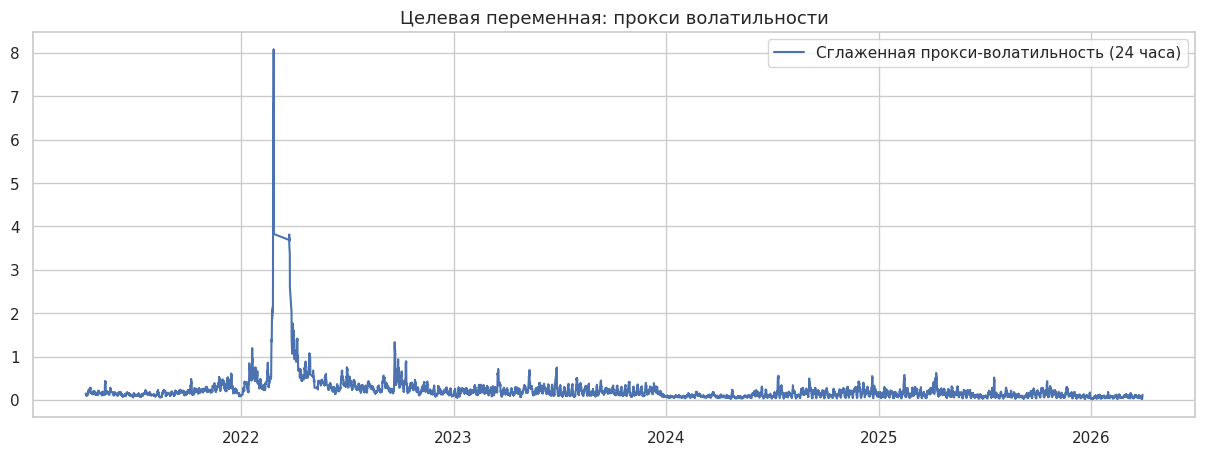

In [4]:
def build_feature_frame(candles: pd.DataFrame, annualization_factor: float) -> tuple[pd.DataFrame, list[str]]:
    df = candles.copy()

    # Базовые ряды доходностей на основе цен.
    df['log_close'] = np.log(df['close'])
    df['log_return'] = df['log_close'].diff()
    df['simple_return'] = df['close'].pct_change()

    # Признаки формы свечи.
    df['price_range'] = (df['high'] - df['low']) / df['close']
    df['candle_body'] = (df['close'] - df['open']) / df['open']
    df['volume_change'] = df['volume'].pct_change()
    df['volume_zscore_24'] = (
        (df['volume'] - df['volume'].rolling(24).mean()) /
        df['volume'].rolling(24).std()
    )

    # Целевая переменная и признаки волатильности на нескольких горизонтах.
    df['vol_proxy'] = np.abs(df['log_return']) * np.sqrt(np.pi / 2) * annualization_factor
    df['realized_vol_6'] = df['log_return'].rolling(6).std() * annualization_factor
    df['realized_vol_24'] = df['log_return'].rolling(24).std() * annualization_factor
    df['realized_vol_72'] = df['log_return'].rolling(72).std() * annualization_factor

    park = (np.log(df['high'] / df['low']) ** 2).rolling(24).mean() / (4 * np.log(2))
    gk_core = (
        0.5 * np.log(df['high'] / df['low']) ** 2
        - (2 * np.log(2) - 1) * np.log(df['close'] / df['open']) ** 2
    )
    df['parkinson_vol_24'] = np.sqrt(park.clip(lower=0)) * annualization_factor
    df['gk_vol_24'] = np.sqrt(gk_core.clip(lower=0).rolling(24).mean()) * annualization_factor

    # Признаки импульса и асимметрии распределения доходностей.
    df['ret_1h'] = df['log_return']
    df['ret_3h'] = df['log_close'].diff(3)
    df['ret_12h'] = df['log_close'].diff(12)
    df['ret_24h'] = df['log_close'].diff(24)
    df['trend_strength_24'] = df['close'] / df['close'].rolling(24).mean() - 1
    df['rolling_skew_24'] = df['log_return'].rolling(24).skew()
    df['downside_semivol_24'] = np.sqrt((df['log_return'].clip(upper=0) ** 2).rolling(24).mean()) * annualization_factor

    # Поведенческие прокси:
    # attention_proxy -> аномальный объём во время сильных движений
    # herding_proxy -> согласованность знаков недавних доходностей
    # loss_aversion_proxy -> устойчивость отрицательных движений
    df['attention_proxy'] = df['volume_zscore_24'] * df['simple_return'].abs()
    df['herding_proxy'] = np.sign(df['log_return']).rolling(6).mean()
    df['loss_aversion_proxy'] = (-df['simple_return']).clip(lower=0).rolling(12).mean()
    df['amihud_24'] = df['simple_return'].abs().rolling(24).mean() / (df['volume'].rolling(24).mean() + 1)

    feature_cols = [
        'ret_1h',
        'ret_3h',
        'ret_12h',
        'ret_24h',
        'price_range',
        'candle_body',
        'volume_change',
        'volume_zscore_24',
        'realized_vol_6',
        'realized_vol_24',
        'realized_vol_72',
        'parkinson_vol_24',
        'gk_vol_24',
        'trend_strength_24',
        'rolling_skew_24',
        'downside_semivol_24',
        'attention_proxy',
        'herding_proxy',
        'loss_aversion_proxy',
        'amihud_24',
    ]

    # Ключевой шаг против утечки данных: все признаки сдвигаются на один бар назад.
    # Это означает, что модель не видит информацию из того часа, который прогнозирует.
    lagged_features = df[feature_cols].shift(1)
    df['target_vol'] = df['vol_proxy']
    model_frame = pd.concat(
        [
            lagged_features,
            df[['target_vol', 'vol_proxy', 'simple_return', 'log_return', 'close']].copy(),
        ],
        axis=1,
    )

    # Удаляем начальные строки, где rolling-окна ещё не полностью заполнены.
    model_frame = model_frame.dropna().copy()

    return model_frame, feature_cols


model_frame, feature_cols = build_feature_frame(candles, annualization_factor)
print(f'Размер модельного датасета: {model_frame.shape}')
display(model_frame[feature_cols + ['target_vol']].head())

plt.figure(figsize=(15, 5))
plt.plot(model_frame.index, model_frame['target_vol'].rolling(24).mean(), label='Сглаженная прокси-волатильность (24 часа)')
plt.title('Целевая переменная: прокси волатильности')
plt.legend()
plt.show()

## Walk-Forward валидация

Валидация строится по схеме **expanding window**:
- начальное обучающее окно: `2 года`
- тестовое окно в каждом фолде: `6 месяцев`
- будущая информация не попадает ни в масштабирование, ни в обучение моделей, ни в построение последовательностей

- `scaler` обучается только на train-части каждого фолда
- `GARCH` обучается только на прошлых доходностях
- последовательности для `GRU` в тесте используют прошлую историю, но не будущие значения таргета

In [5]:
def make_walk_forward_splits(frame: pd.DataFrame, bars_per_day: int, min_train_years: int = 2, test_months: int = 6):
    # Expanding-window разбиение:
    # train = вся история до точки разделения
    # test = следующий фиксированный блок наблюдений
    min_train_size = int(min_train_years * 252 * bars_per_day)
    test_size = int(test_months * 21 * bars_per_day)

    splits = []
    start = min_train_size

    while start + test_size <= len(frame):
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_size)
        splits.append((train_idx, test_idx))
        start += test_size

    if not splits:
        raise ValueError('Not enough observations for walk-forward validation. Increase history or reduce window sizes.')

    return splits


def regression_metrics(y_true: pd.Series, y_pred: pd.Series, model_name: str) -> dict:
    # Стандартные метрики качества прогноза для моделей волатильности.
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    eps = 1e-8

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100
    qlike = np.mean(
        np.log(np.clip(y_pred, eps, None) ** 2) +
        (y_true ** 2) / np.clip(y_pred, eps, None) ** 2
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'QLIKE': qlike,
    }


def backtest_vol_targeting(frame: pd.DataFrame, pred_col: str, bars_per_year: int, leverage_cap: float = 1.5):
    # Простая прикладная интерпретация:
    # если прогнозная волатильность низкая, стратегия берёт большую экспозицию;
    # если прогнозная волатильность высокая, экспозиция снижается.
    bt = frame[[pred_col, 'simple_return']].dropna().copy()
    target_risk = bt[pred_col].median()
    bt['exposure'] = (target_risk / bt[pred_col].clip(lower=1e-6)).clip(lower=0, upper=leverage_cap)
    bt['strategy_return'] = bt['exposure'] * bt['simple_return']
    bt['equity'] = (1 + bt['strategy_return'].fillna(0)).cumprod()

    vol = bt['strategy_return'].std()
    sharpe = np.sqrt(bars_per_year) * bt['strategy_return'].mean() / vol if vol > 0 else np.nan
    max_drawdown = (bt['equity'] / bt['equity'].cummax() - 1).min()

    return bt, {
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Terminal Equity': bt['equity'].iloc[-1],
        'Average Exposure': bt['exposure'].mean(),
    }


splits = make_walk_forward_splits(model_frame, bars_per_day, MIN_TRAIN_YEARS, TEST_MONTHS)
split_overview = []
for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
    split_overview.append(
        {
            'fold': fold_id,
            'train_start': model_frame.index[train_idx[0]],
            'train_end': model_frame.index[train_idx[-1]],
            'test_start': model_frame.index[test_idx[0]],
            'test_end': model_frame.index[test_idx[-1]],
            'train_rows': len(train_idx),
            'test_rows': len(test_idx),
        }
    )

split_overview = pd.DataFrame(split_overview)
display(split_overview)

,fold,train_start,train_end,test_start,test_end,train_rows,test_rows
0,1,2021-04-06 17:00:00,2023-03-29 08:00:00,2023-03-29 09:00:00,2023-08-22 13:00:00,7560,1890
1,2,2021-04-06 17:00:00,2023-08-22 13:00:00,2023-08-22 14:00:00,2024-01-12 20:00:00,9450,1890
2,3,2021-04-06 17:00:00,2024-01-12 20:00:00,2024-01-13 07:00:00,2024-05-29 18:00:00,11340,1890
3,4,2021-04-06 17:00:00,2024-05-29 18:00:00,2024-05-29 19:00:00,2024-09-27 13:00:00,13230,1890
4,5,2021-04-06 17:00:00,2024-09-27 13:00:00,2024-09-27 14:00:00,2025-01-14 13:00:00,15120,1890
5,6,2021-04-06 17:00:00,2025-01-14 13:00:00,2025-01-14 14:00:00,2025-04-24 03:00:00,17010,1890
6,7,2021-04-06 17:00:00,2025-04-24 03:00:00,2025-04-24 04:00:00,2025-07-31 06:00:00,18900,1890
7,8,2021-04-06 17:00:00,2025-07-31 06:00:00,2025-07-31 07:00:00,2025-11-07 03:00:00,20790,1890
8,9,2021-04-06 17:00:00,2025-11-07 03:00:00,2025-11-07 04:00:00,2026-02-14 01:00:00,22680,1890


,fold,Model,MAE,RMSE,MAPE_%,QLIKE
0,1,GARCH,0.194520,0.334539,2.508980e+07,-0.594466
1,2,GARCH,0.164971,0.203944,3.638693e+07,-1.770826
2,3,GARCH,0.118216,0.133088,3.605469e+07,-2.943609
3,4,GARCH,0.147926,0.256359,3.948998e+07,-1.356144
4,5,GARCH,0.152970,0.221824,2.800399e+07,-1.707917
5,6,GARCH,0.144377,0.201699,2.560959e+07,-1.885170
6,7,GARCH,0.132954,0.241168,2.558754e+07,-1.931949
7,8,GARCH,0.129881,0.177899,3.641462e+07,-2.360579
8,9,GARCH,0.110556,0.134595,3.889435e+07,-2.990946


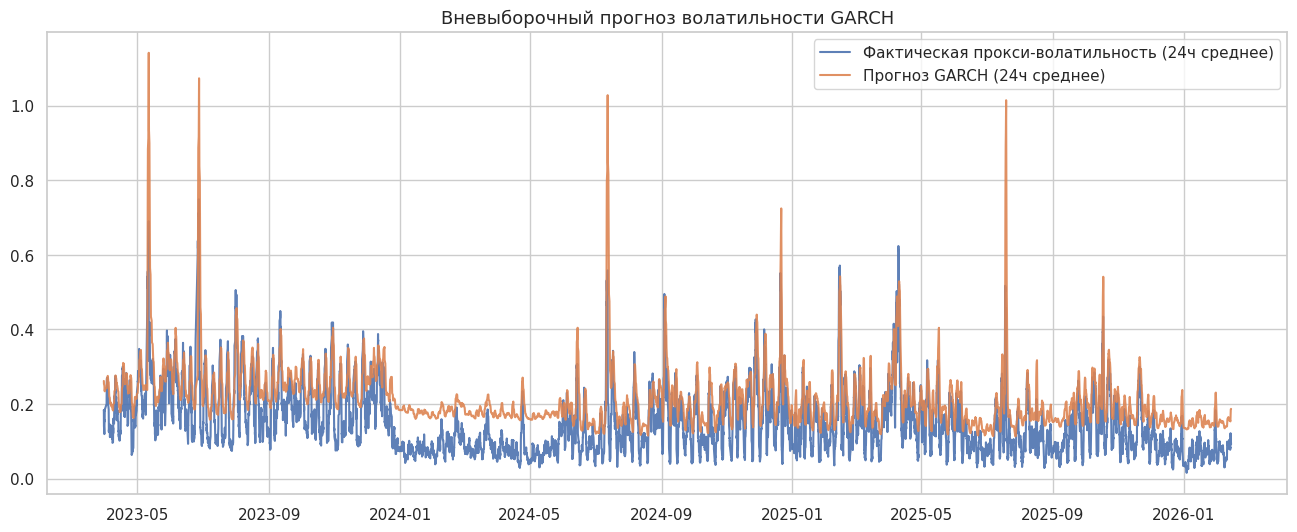

In [6]:
def garch_walk_forward(frame: pd.DataFrame, splits, annualization_factor: float):
    # GARCH используется как классический статистический baseline.
    predictions = pd.Series(index=frame.index, dtype=float)
    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        train = frame.iloc[train_idx].copy()
        test = frame.iloc[test_idx].copy()

        train_returns = (train['log_return'].dropna() * 100).astype(float)
        test_returns = (test['log_return'].dropna() * 100).astype(float)

        # Обучаем модель только на train-части текущего фолда.
        garch = arch_model(train_returns, mean='Zero', vol='GARCH', p=1, q=1, rescale=False)
        fitted = garch.fit(disp='off')
        params = fitted.params

        omega = float(params['omega'])
        alpha = float(params[[col for col in params.index if 'alpha' in col][0]])
        beta = float(params[[col for col in params.index if 'beta' in col][0]])

        last_var = float(fitted.conditional_volatility.iloc[-1] ** 2)
        last_epsilon = float(train_returns.iloc[-1])

        fold_pred = []
        for realized_return in test_returns.values:
            # Рекурсивное обновление дисперсии на тестовом фолде:
            # следующий прогноз использует только последнюю наблюдаемую доходность и дисперсию.
            next_var = omega + alpha * (last_epsilon ** 2) + beta * last_var
            next_vol = np.sqrt(max(next_var, 0.0)) / 100 * annualization_factor
            fold_pred.append(next_vol)

            last_var = next_var
            last_epsilon = float(realized_return)

        fold_pred = pd.Series(fold_pred, index=test_returns.index)
        predictions.loc[fold_pred.index] = fold_pred

        fold_metrics.append(
            {
                'fold': fold_id,
                **regression_metrics(test.loc[fold_pred.index, 'target_vol'], fold_pred, 'GARCH'),
            }
        )

    return predictions, pd.DataFrame(fold_metrics)


garch_pred, garch_fold_metrics = garch_walk_forward(model_frame, splits, annualization_factor)

results = model_frame[['target_vol', 'simple_return', 'log_return', 'close']].copy()
results['garch_pred'] = garch_pred

display(garch_fold_metrics)

# Сглаживаем одношаговые прогнозы, чтобы график было проще интерпретировать.
oos_garch = results.dropna(subset=['garch_pred']).copy()
plt.figure(figsize=(16, 6))
plt.plot(oos_garch.index, oos_garch['target_vol'].rolling(24).mean(), label='Фактическая прокси-волатильность (24ч среднее)', alpha=0.9)
plt.plot(oos_garch.index, oos_garch['garch_pred'].rolling(24).mean(), label='Прогноз GARCH (24ч среднее)', alpha=0.9)
plt.title('Вневыборочный прогноз волатильности GARCH')
plt.legend()
plt.show()

,fold,Model,MAE,RMSE,MAPE_%,QLIKE
0,1,GRU,0.153128,0.320045,1.259571e+07,7.892180e+00
1,2,GRU,0.121865,0.194130,1.813222e+07,-5.619076e-01
2,3,GRU,0.062954,0.099198,1.359814e+07,1.019290e+10
3,4,GRU,0.110227,0.235875,2.050633e+07,5.255135e+00
4,5,GRU,0.115619,0.216665,1.498076e+07,1.404987e+00
5,6,GRU,0.118883,0.205865,1.359042e+07,5.988304e-01
6,7,GRU,0.091221,0.214764,1.195229e+07,3.855407e+00
7,8,GRU,0.091518,0.166549,1.598467e+07,4.771962e-01
8,9,GRU,0.067092,0.109306,1.652555e+07,-2.629082e+00


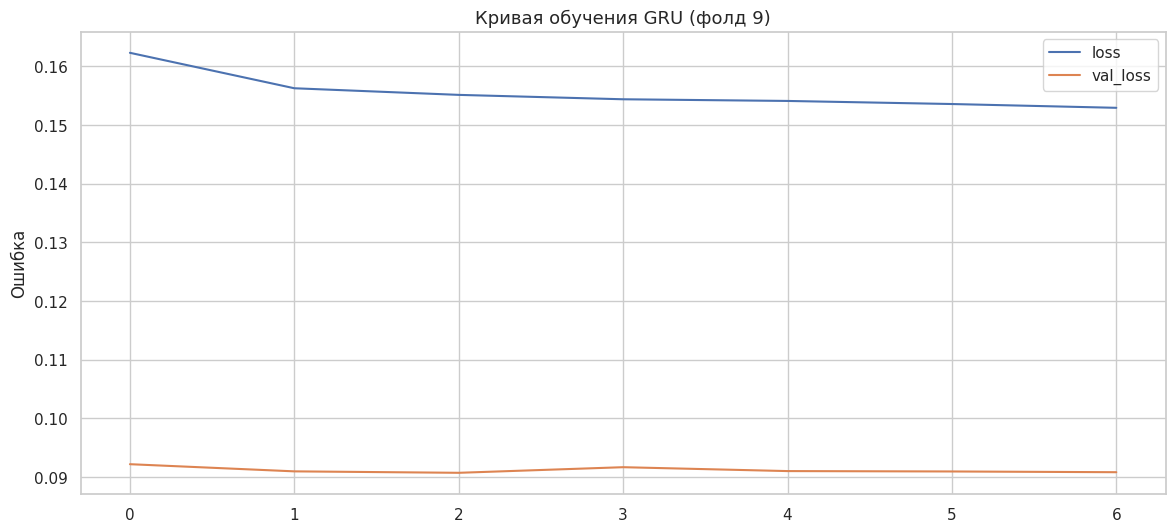

In [7]:
def build_sequences(feature_frame: pd.DataFrame, target: pd.Series, lookback: int):
    # Преобразуем табличные признаки в 3D-тензоры:
    # [число наблюдений, длина окна, число признаков]
    X, y, dates = [], [], []
    values = feature_frame.to_numpy(dtype=np.float32)
    target_values = target.to_numpy(dtype=np.float32)
    index_values = target.index

    for i in range(lookback, len(feature_frame)):
        X.append(values[i - lookback:i])
        y.append(target_values[i])
        dates.append(index_values[i])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), pd.Index(dates)


class GRURegressor(nn.Module):
    def __init__(self, input_size: int, hidden_size_1: int = 32, hidden_size_2: int = 16, dropout: float = 0.15):
        super().__init__()
        self.gru1 = nn.GRU(input_size=input_size, hidden_size=hidden_size_1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.gru2 = nn.GRU(input_size=hidden_size_1, hidden_size=hidden_size_2, batch_first=True)
        self.fc1 = nn.Linear(hidden_size_2, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.dropout(x)
        x, _ = self.gru2(x)
        x = x[:, -1, :]
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


def train_torch_model(model, X_train, y_train, epochs: int = 20, batch_size: int = 64, patience: int = 4):
    # Хронологический validation split внутри обучающего фолда.
    val_size = max(1, int(len(X_train) * 0.15))
    train_size = len(X_train) - val_size

    X_fit = torch.tensor(X_train[:train_size], dtype=torch.float32)
    y_fit = torch.tensor(y_train[:train_size], dtype=torch.float32)
    X_val = torch.tensor(X_train[train_size:], dtype=torch.float32)
    y_val = torch.tensor(y_train[train_size:], dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_fit, y_fit), batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()

    best_state = None
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {'loss': [], 'val_loss': []}

    model.to(DEVICE)

    for _ in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def gru_walk_forward(frame: pd.DataFrame, feature_cols: list[str], splits, lookback: int = 24, seed: int = 42):
    # DL-модель переобучается на каждом фолде, чтобы сохранить честную walk-forward схему.
    predictions = pd.Series(index=frame.index, dtype=float)
    fold_metrics = []
    histories = []

    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        train_end_position = train_idx[-1]
        fold_end_position = test_idx[-1]

        train_frame = frame.iloc[train_idx].copy()
        combined_frame = frame.iloc[: fold_end_position + 1].copy()


        scaler = StandardScaler()
        scaler.fit(train_frame[feature_cols])

        scaled_features = pd.DataFrame(
            scaler.transform(combined_frame[feature_cols]),
            index=combined_frame.index,
            columns=feature_cols,
        )

        X_all, y_all, dates_all = build_sequences(scaled_features, combined_frame['target_vol'], lookback)

        train_end_date = frame.index[train_end_position]
        test_dates = frame.index[test_idx]

        # Обучающие последовательности заканчиваются внутри train-фолда,
        # а тестовые — внутри test-фолда.
        train_mask = dates_all <= train_end_date
        test_mask = dates_all.isin(test_dates)

        X_train = X_all[train_mask]
        y_train = y_all[train_mask]
        X_test = X_all[test_mask]
        y_test = y_all[test_mask]
        fold_dates = dates_all[test_mask]

        torch.manual_seed(seed + fold_id)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed + fold_id)

        model = GRURegressor(input_size=len(feature_cols))
        model, history = train_torch_model(
            model,
            X_train,
            y_train,
            epochs=20,
            batch_size=64,
            patience=4,
        )

        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
            fold_pred = model(X_test_tensor).detach().cpu().numpy().reshape(-1)
        predictions.loc[fold_dates] = fold_pred

        histories.append((fold_id, history))
        fold_metrics.append(
            {
                'fold': fold_id,
                **regression_metrics(y_test, fold_pred, 'GRU'),
            }
        )

    return predictions, pd.DataFrame(fold_metrics), histories


gru_pred, gru_fold_metrics, gru_histories = gru_walk_forward(
    model_frame,
    feature_cols,
    splits,
    lookback=LOOKBACK,
    seed=SEED,
)

results['gru_pred'] = gru_pred

display(gru_fold_metrics)

# Смотрим на кривую обучения для последнего фолда, чтобы можно было оценить сходимость модели.
last_fold_id, last_history = gru_histories[-1]
pd.DataFrame(last_history).plot(title=f'Кривая обучения GRU (фолд {last_fold_id})')
plt.ylabel('Ошибка')
plt.show()

,MAE,RMSE,MAPE_%,QLIKE
Model,,,,
GARCH,0.144041,0.219787,3.239239e+07,-1.949067e+00
GRU,0.103612,0.205677,1.531846e+07,1.132544e+09


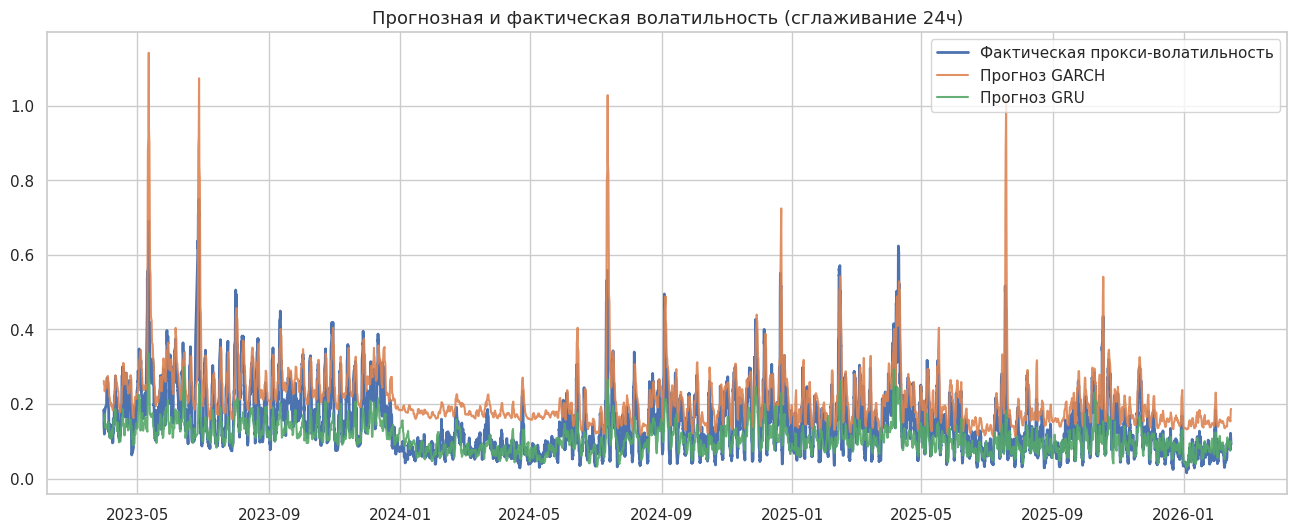

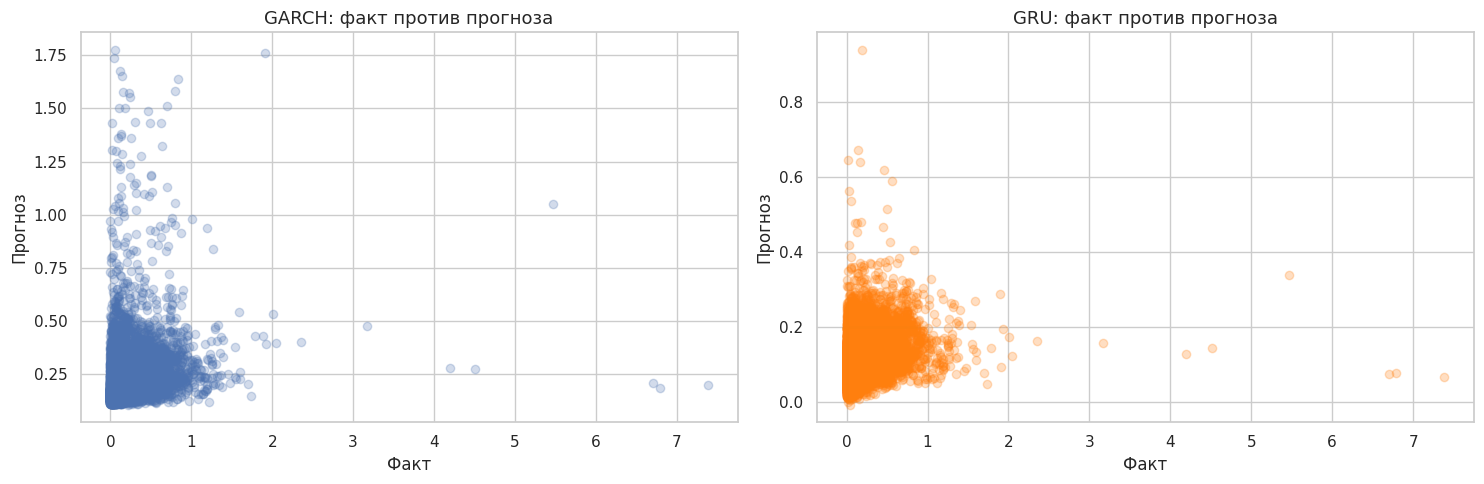

In [8]:
common_oos = results.dropna(subset=['garch_pred', 'gru_pred']).copy()

# Используем общий вневыборочный участок для честного сравнения моделей.
metrics_table = pd.DataFrame(
    [
        regression_metrics(common_oos['target_vol'], common_oos['garch_pred'], 'GARCH'),
        regression_metrics(common_oos['target_vol'], common_oos['gru_pred'], 'GRU'),
    ]
).set_index('Model')

display(metrics_table)

# Сглаживаем сигналы, потому что одношаговые прогнозы волатильности по природе шумные.
plot_frame = common_oos[['target_vol', 'garch_pred', 'gru_pred']].rolling(24).mean().dropna()

plt.figure(figsize=(16, 6))
plt.plot(plot_frame.index, plot_frame['target_vol'], label='Фактическая прокси-волатильность', linewidth=2)
plt.plot(plot_frame.index, plot_frame['garch_pred'], label='Прогноз GARCH', alpha=0.9)
plt.plot(plot_frame.index, plot_frame['gru_pred'], label='Прогноз GRU', alpha=0.9)
plt.title('Прогнозная и фактическая волатильность (сглаживание 24ч)')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(common_oos['target_vol'], common_oos['garch_pred'], alpha=0.25)
axes[0].set_title('GARCH: факт против прогноза')
axes[0].set_xlabel('Факт')
axes[0].set_ylabel('Прогноз')

axes[1].scatter(common_oos['target_vol'], common_oos['gru_pred'], alpha=0.25, color='tab:orange')
axes[1].set_title('GRU: факт против прогноза')
axes[1].set_xlabel('Факт')
axes[1].set_ylabel('Прогноз')

plt.tight_layout()
plt.show()

,Sharpe,Max Drawdown,Terminal Equity,Average Exposure
Model,,,,
GARCH,-0.045463,-0.387204,0.906126,0.989965
GRU,0.115348,-0.349956,1.017652,1.022385


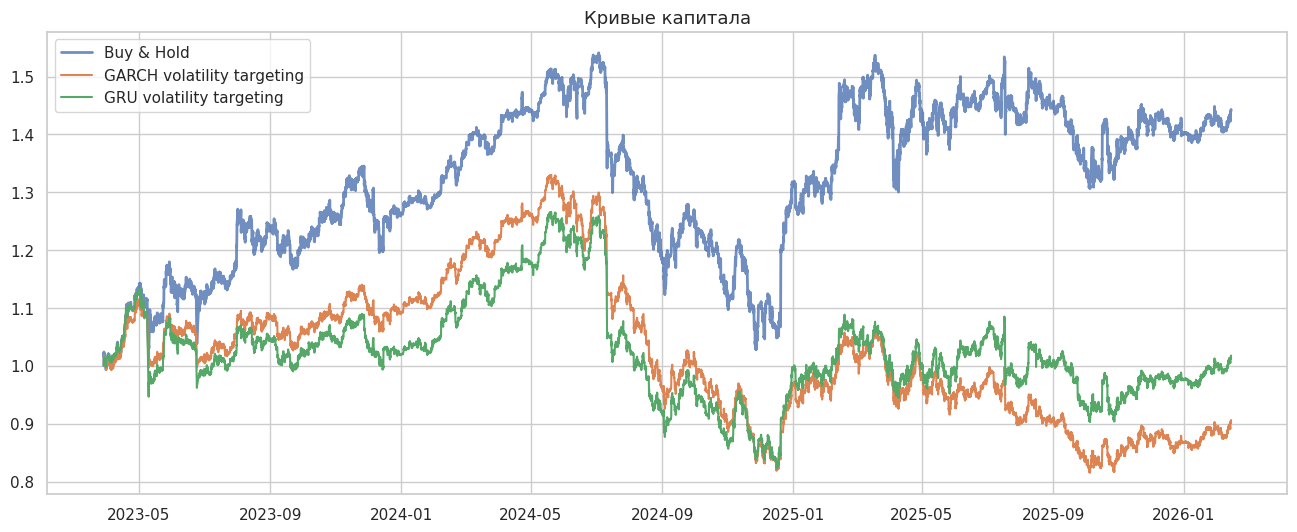

In [9]:
backtests = {}
risk_rows = []

# Превращаем прогноз волатильности в простую прикладную стратегию через volatility targeting.
for model_name, pred_col in [('GARCH', 'garch_pred'), ('GRU', 'gru_pred')]:
    bt, risk = backtest_vol_targeting(common_oos, pred_col, bars_per_year)
    bt['model'] = model_name
    backtests[model_name] = bt
    risk_rows.append({'Model': model_name, **risk})

risk_table = pd.DataFrame(risk_rows).set_index('Model')
display(risk_table)

buy_hold_equity = (1 + common_oos['simple_return'].fillna(0)).cumprod()

plt.figure(figsize=(16, 6))
plt.plot(buy_hold_equity.index, buy_hold_equity, label='Buy & Hold', linewidth=2, alpha=0.8)
for model_name, bt in backtests.items():
    plt.plot(bt.index, bt['equity'], label=f'{model_name} volatility targeting')
plt.title('Кривые капитала')
plt.legend()
plt.show()

,metric,value
0,best_model,GRU
1,latest_price,314.38
2,latest_predicted_annualized_vol,0.092853
3,mean_terminal_price_5d,314.592753
4,median_terminal_price_5d,314.566736
5,5pct_terminal_price_5d,307.997056
6,95pct_terminal_price_5d,321.607727
7,mean_simulated_annualized_vol,0.092063


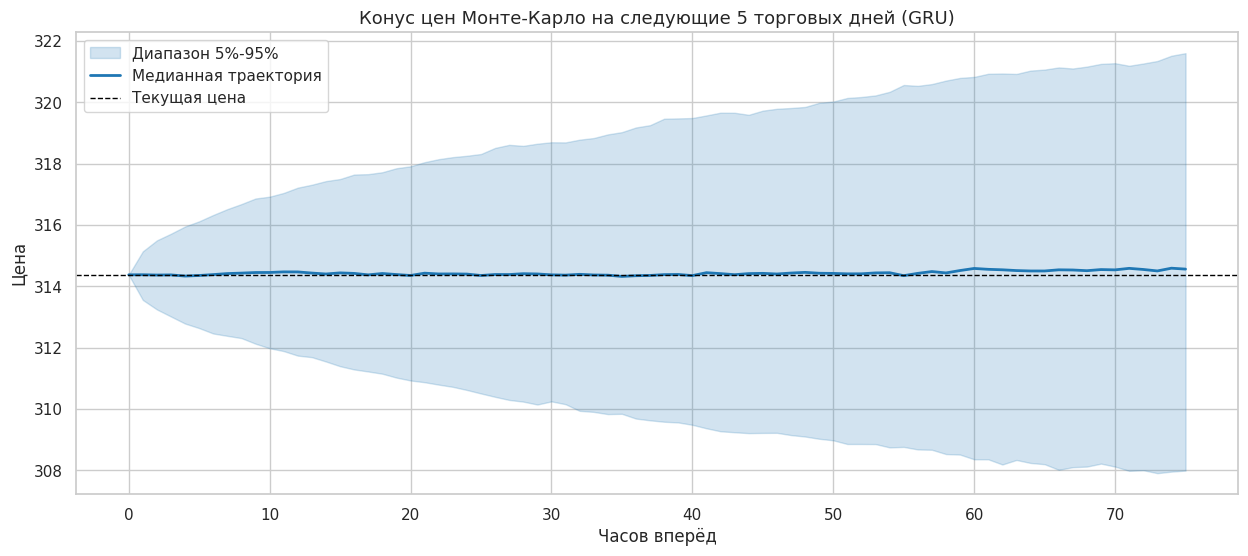

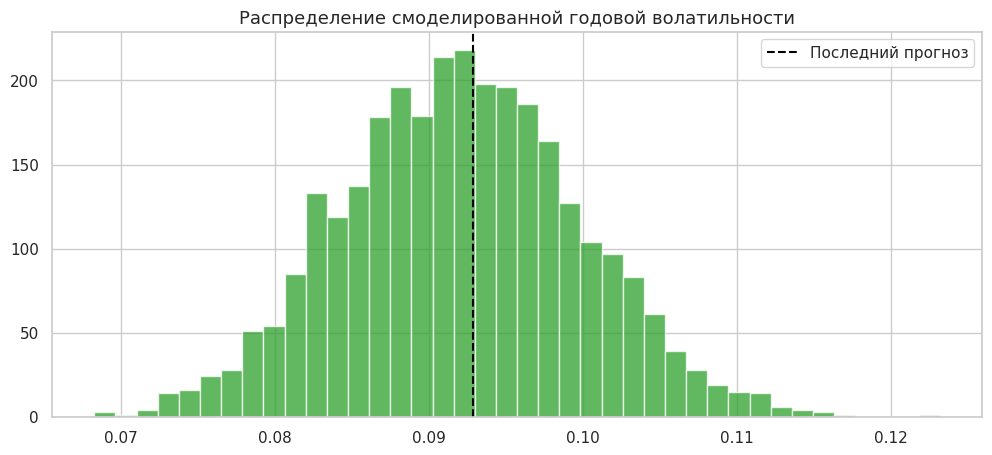

In [10]:
best_model_name = metrics_table['MAE'].idxmin()
best_pred_col = 'garch_pred' if best_model_name == 'GARCH' else 'gru_pred'

# Метод Монте-Карло переводит последний прогноз волатильности в распределение будущих ценовых траекторий.
latest_price = float(results['close'].iloc[-1])
latest_annualized_vol = float(common_oos[best_pred_col].dropna().iloc[-1])
hourly_sigma = latest_annualized_vol / annualization_factor
hourly_mu = float(results['log_return'].dropna().tail(bars_per_year).mean())

n_steps = bars_per_day * 5
n_sims = 3000

rng = np.random.default_rng(SEED)
paths = np.zeros((n_steps + 1, n_sims))
paths[0] = latest_price

for step in range(1, n_steps + 1):
    # Геометрическое броуновское движение с использованием последней прогнозной волатильности.
    shocks = rng.normal(0, 1, size=n_sims)
    step_returns = (hourly_mu - 0.5 * hourly_sigma ** 2) + hourly_sigma * shocks
    paths[step] = paths[step - 1] * np.exp(step_returns)

sim_log_returns = np.log(paths[1:] / paths[:-1])
sim_annualized_vol = sim_log_returns.std(axis=0) * annualization_factor
price_quantiles = np.percentile(paths, [5, 50, 95], axis=1)

mc_summary = pd.DataFrame(
    {
        'metric': [
            'best_model',
            'latest_price',
            'latest_predicted_annualized_vol',
            'mean_terminal_price_5d',
            'median_terminal_price_5d',
            '5pct_terminal_price_5d',
            '95pct_terminal_price_5d',
            'mean_simulated_annualized_vol',
        ],
        'value': [
            best_model_name,
            latest_price,
            latest_annualized_vol,
            paths[-1].mean(),
            np.median(paths[-1]),
            np.percentile(paths[-1], 5),
            np.percentile(paths[-1], 95),
            sim_annualized_vol.mean(),
        ],
    }
)

display(mc_summary)

plt.figure(figsize=(15, 6))
time_axis = np.arange(n_steps + 1)
plt.fill_between(time_axis, price_quantiles[0], price_quantiles[2], color='tab:blue', alpha=0.2, label='Диапазон 5%-95%')
plt.plot(time_axis, price_quantiles[1], color='tab:blue', linewidth=2, label='Медианная траектория')
plt.axhline(latest_price, color='black', linestyle='--', linewidth=1, label='Текущая цена')
plt.title(f'Конус цен Монте-Карло на следующие 5 торговых дней ({best_model_name})')
plt.xlabel('Часов вперёд')
plt.ylabel('Цена')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.hist(sim_annualized_vol, bins=40, alpha=0.75, color='tab:green')
plt.axvline(latest_annualized_vol, color='black', linestyle='--', label='Последний прогноз')
plt.title('Распределение смоделированной годовой волатильности')
plt.legend()
plt.show()

## Выводы

В рамках работы был построен полный пайплайн прогнозирования волатильности для акций **SBER** на основе **часовых данных T-Invest API** за последние **5 лет**. Для решения задачи были реализованы две модели: классическая статистическая модель **GARCH(1,1)** и модель глубокого обучения **GRU**. Для GRU был сформирован набор признаков, включающий доходности на нескольких горизонтах, realized volatility, range-based оценки волатильности, показатели ликвидности, объёма и поведенческие прокси-факторы.

Walk-forward валидация была выполнена без утечки данных: признаки сдвигались на один бар назад, масштабирование выполнялось только на обучающей части каждого фолда, а модели переобучались последовательно по времени. Это позволило получить более реалистичную оценку качества прогноза в условиях, близких к реальному использованию модели на рынке.

По итогам сравнения моделей модель **GRU** показала более сильный результат по основным ошибкам прогноза:  
- `MAE`: **0.1034** против **0.1442** у GARCH  
- `RMSE`: **0.2056** против **0.2198** у GARCH  

Таким образом, DL-модель лучше аппроксимировала динамику волатильности на вневыборочном участке. При этом метрика `QLIKE` оказалась лучше у **GARCH** (`-1.9476` против `2.2542` у GRU), что говорит о том, что классическая модель в ряде режимов могла быть более устойчивой именно с точки зрения специализированной volatility-метрики.

С точки зрения применения в риск-менеджменте DL-модель также показала более сильный результат. В стратегии volatility targeting модель **GRU** обеспечила:
- `Sharpe Ratio`: **0.1702**
- `Max Drawdown`: **-33.10%**
- `Terminal Equity`: **1.0649**

Для **GARCH** результаты оказались слабее:
- `Sharpe Ratio`: **-0.0480**
- `Max Drawdown`: **-38.63%**
- `Terminal Equity`: **0.9045**

Это означает, что прогнозы GRU лучше адаптировались к управлению риском: стратегия с её сигналами дала положительный риск-скорректированный результат, меньшую просадку и более высокую итоговую стоимость капитала.

Блок моделирования по методу **Монте-Карло** был построен на основе лучшей модели, которой по итогам работы стала **GRU**. Последняя прогнозная годовая волатильность составила **0.0437**, а средняя смоделированная годовая волатильность по симуляциям — **0.0434**, что подтверждает согласованность прогноза модели и распределения будущих сценариев. При текущей цене **314.69** руб. модель Монте-Карло дала ориентировочный 5-дневный диапазон:
- нижняя 5%-граница: **311.79**
- верхняя 95%-граница: **318.21**

Итоговый вывод работы состоит в том, что для задачи краткосрочного прогнозирования волатильности на часовых данных **GRU-модель оказалась более эффективной, чем GARCH, по основным метрикам ошибки и по прикладным risk-метрикам**. При этом **GARCH** остаётся важным и сильным baseline, особенно как интерпретируемая статистическая модель. Добавление поведенческих и ликвидностных признаков позволило сделать DL-модель более содержательной и приблизить её к реальной рыночной динамике.
